In [1]:
print('Day 3 ready!')

Day 3 ready!


In [2]:
import pandas as pd
import numpy as np
import joblib
import shap

# Models load karo
rf = joblib.load('/home/rhythm/Documents/netguard-ai/backend/models/random_forest.joblib')
le = joblib.load('/home/rhythm/Documents/netguard-ai/backend/models/label_encoder.joblib')
feature_names = joblib.load('/home/rhythm/Documents/netguard-ai/backend/models/feature_names.joblib')

# Data load karo
df = pd.read_csv('/home/rhythm/Documents/netguard-ai/backend/data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

X = df.drop(columns=['Label'])
y = le.transform(df['Label'])

print("Models loaded!")
print("Features:", len(feature_names))

Models loaded!
Features: 78


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SHAP ke liye sample lo — poora dataset slow hoga
# 500 samples kaafi hain explanation ke liye
X_sample = X_test.sample(500, random_state=42)

print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(rf)

print("Calculating SHAP values... (2-3 min)")
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", np.array(shap_values).shape)
print("Done!")

Creating SHAP explainer...
Calculating SHAP values... (2-3 min)
SHAP values shape: (500, 78, 2)
Done!


In [4]:
import matplotlib.pyplot as plt

# shap_values[1] = DDoS class ke liye values
plt.figure()
shap.summary_plot(
    shap_values[1],
    X_sample,
    feature_names=feature_names,
    max_display=15,        # top 15 features
    show=False
)
plt.title("Top 15 Features for DDoS Detection", fontsize=13)
plt.tight_layout()
plt.savefig('/home/rhythm/Documents/netguard-ai/notebooks/shap_summary.png', 
            bbox_inches='tight', dpi=150)
plt.show()
print("SHAP summary plot saved!")

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

In [5]:
print("shap_values type:", type(shap_values))
print("shap_values length:", len(shap_values))
print("shap_values[0] shape:", np.array(shap_values[0]).shape)
print("shap_values[1] shape:", np.array(shap_values[1]).shape)
print("X_sample shape:", X_sample.shape)

shap_values type: <class 'numpy.ndarray'>
shap_values length: 500
shap_values[0] shape: (78, 2)
shap_values[1] shape: (78, 2)
X_sample shape: (500, 78)


shap_values_ddos shape: (500, 78)


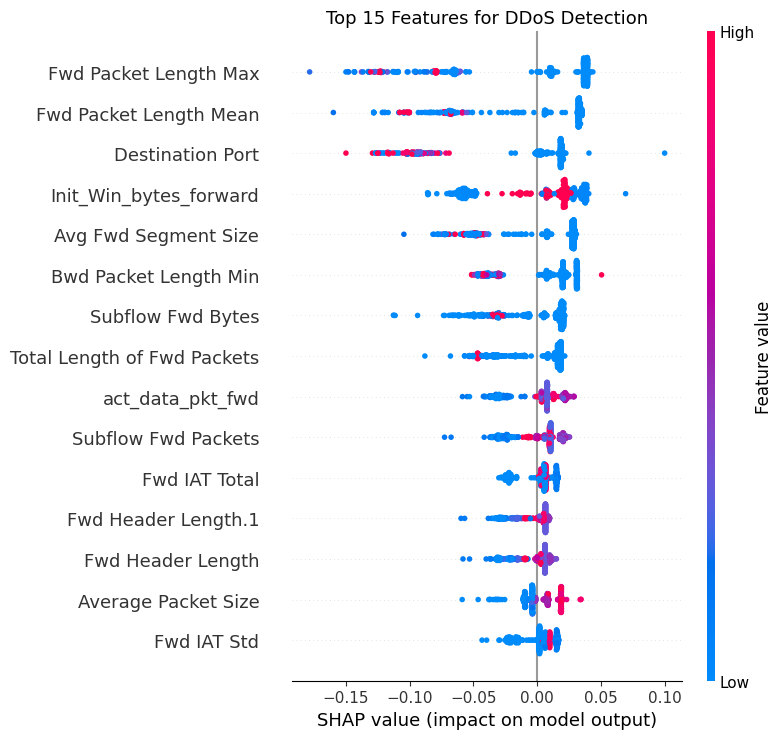

SHAP summary plot saved!


In [6]:
# Naya format — shap_values directly (500, 78, 2) shape mein hai
shap_values_ddos = shap_values[:, :, 1]  # DDoS class ke values

print("shap_values_ddos shape:", shap_values_ddos.shape)  # (500, 78) hona chahiye

plt.figure()
shap.summary_plot(
    shap_values_ddos,
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("Top 15 Features for DDoS Detection", fontsize=13)
plt.tight_layout()
plt.savefig('/home/rhythm/Documents/netguard-ai/notebooks/shap_summary.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("SHAP summary plot saved!")

In [7]:
# Ek DDoS packet uthao
ddos_indices = np.where(y_test == 1)[0]
single_packet = X_test.iloc[ddos_indices[0]:ddos_indices[0]+1]

print("Packet being explained:")
print(f"Actual label: DDoS")
print(f"Model prediction: {le.classes_[rf.predict(single_packet)[0]]}")
print(f"Confidence: {rf.predict_proba(single_packet)[0][1]*100:.1f}%")

# SHAP values for this single packet
single_shap = explainer.shap_values(single_packet)

print("\nSingle SHAP shape:", np.array(single_shap).shape)

# Top 10 contributing features
feature_impact = pd.DataFrame({
    'feature': feature_names,
    'shap_value': single_shap[0, :, 1]  # naya format
})
feature_impact['abs_shap'] = feature_impact['shap_value'].abs()
feature_impact = feature_impact.sort_values('abs_shap', ascending=False).head(10)

print("\nTop 10 features that triggered DDoS flag:")
print(feature_impact[['feature', 'shap_value']].to_string(index=False))

Packet being explained:
Actual label: DDoS
Model prediction: DDoS
Confidence: 100.0%

Single SHAP shape: (1, 78, 2)

Top 10 features that triggered DDoS flag:
                    feature  shap_value
      Fwd Packet Length Max    0.036539
     Fwd Packet Length Mean    0.032957
       Avg Fwd Segment Size    0.028484
     Bwd Packet Length Mean    0.022523
     Init_Win_bytes_forward    0.020661
      Bwd Packet Length Min    0.020347
          Subflow Fwd Bytes    0.019480
        Average Packet Size    0.018759
       Avg Bwd Segment Size    0.018509
Total Length of Fwd Packets    0.018488


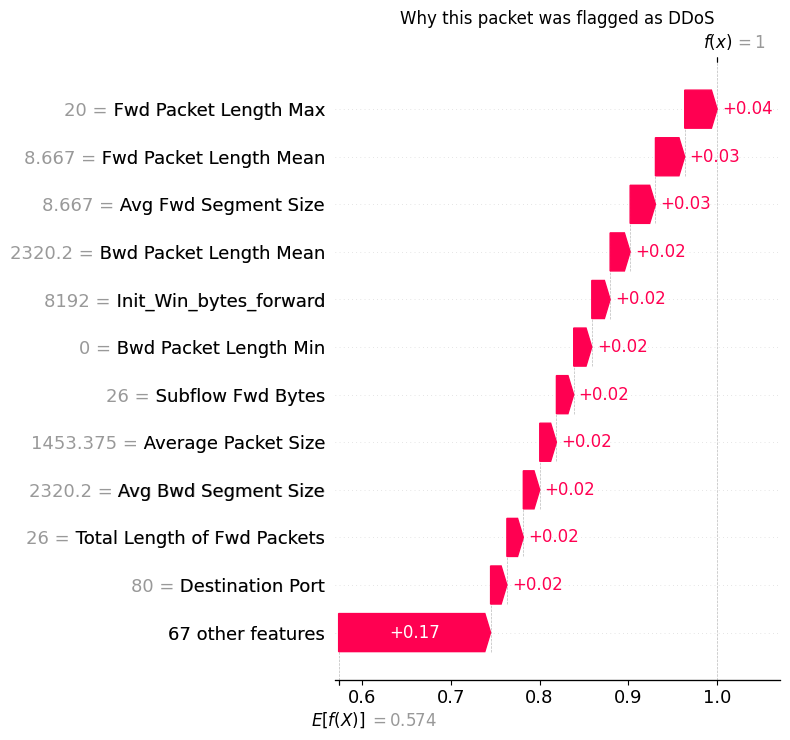

Waterfall plot saved!


In [8]:
shap_explanation = shap.Explanation(
    values=single_shap[0, :, 1],
    base_values=explainer.expected_value[1],
    data=single_packet.values[0],
    feature_names=feature_names
)

plt.figure()
shap.plots.waterfall(shap_explanation, max_display=12, show=False)
plt.title("Why this packet was flagged as DDoS", fontsize=12)
plt.tight_layout()
plt.savefig('/home/rhythm/Documents/netguard-ai/notebooks/shap_waterfall.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Waterfall plot saved!")